In [144]:
# limit the thread used by numpy 
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"  

import numpy as np
import scipy.interpolate as interp 
try:
    import cupy as xp
    import cupyx.scipy.interpolate as xinterp
    # print("has cupy")
except (ImportError, ModuleNotFoundError) as e:
    import numpy as xp
    import scipy.interpolate as xinterp  
    # print("no cupy")

from tqdm import tqdm
import pickle
import matplotlib.pyplot as plt
# import matplotlib
# matplotlib.rcParams['text.usetex'] = True
# matplotlib.rcParams['font.family'] = 'serif'

from Triangle.Constants import *
from Triangle.Orbit import * 
from Triangle.Noise import *
from Triangle.FFTTools import *
from Triangle.TDI import *
from Triangle.Data import * 

from Triangle_BBH.Waveform import * 
from Triangle_BBH.Response import FDTDIResponseGenerator
from Triangle_BBH.Utils import Likelihood, Fstatistics
from Triangle_BBH.Fisher import *

# import multiprocessing
# if __name__=='__main__':
#     multiprocessing.set_start_method("fork")
    
import bilby 

# np.random.seed(114517)
# xp.random.seed(114514)

In [145]:
class WaveformGenerator():
    def __init__(self, mode='full'):
        """ 
            vectorized wrapper of the PhenomHM waveform 
            using the Fourier transformation convension of S. Marsat
            h_lm(f) = A_lm(f) exp[i Phi_lm(f)]
            t_lm(f) = d Phi_lm(f) / df / 2PI
            with Phi_lm(f) being -Psi_lm(f) in the paper
            
            mode = 'full': HM waveform
            mode = 'primary': D waveform
        """
        self.waveform = WF.IMRPhenomHM(mode=mode)
    
    def __call__(self, parameters, Nfreqs=1024, fmin=1e-5, fmax=1e-1, freqs=None):
        """  
            parameters = {
                "name" : numpy array of shape (Nevents),
                ...
            }
            the parameters include:
            "chirp_mass" [MSUN], "mass_ratio" [1], "spin_1z" [1], "spin_2z" [1], 
            "coalescence_time" [DAY] (SSB), "coalescence_phase" [rad],
            "luminosity_distance" [MPC], "inclination" [rad], 
            "longitude" [rad], "latitude" [rad], "psi" [rad]
            11 parameters in total
            *** NOTE that coalescence time has to be converted to tc at the SSB origin.
            *** NOTE that coalescence phase parameter is ignored and set to 0
            freqs should be None or numpy array of shape (Nevents, Nfreqs)
            
            Calculate the mode-independent frequency grids of shape (Nevents, Nfreqs), 
            and mode-dependent (Nevents, Nfreqs) arrays of GW amplitudes, phases and t-f relationships, 
            stored in dictionaries with the keys being mode numbers.
            e.g. amps_out = {
                (l, m) : (Nevents, Nfreqs) array,
                ...
            }
        """
        Nevents = np.atleast_1d(parameters["chirp_mass"]).shape[0]
        
        # conversion of parameters
        parameters_in = {}
        parameters_in["Mc"] = np.atleast_1d(parameters["chirp_mass"])
        parameters_in["eta"] = np.atleast_1d(eta_q(parameters["mass_ratio"]))
        parameters_in["chi1z"] = np.atleast_1d(parameters["spin_1z"])
        parameters_in["chi2z"] = np.atleast_1d(parameters["spin_2z"])
        parameters_in["dL"] = np.atleast_1d(parameters["luminosity_distance"] / 1e3) 
        parameters_in['coalescence_time'] = np.atleast_1d(parameters['coalescence_time'])
        
        # calculate frequency grids of shape (Nfreqs, Nevents) (will be transposed later), independent of modes
        # NOTE: for later convenience fgrid must be the same for all events
        if type(freqs) == np.ndarray:
            if freqs.shape[0] == Nevents:
                fgrids = np.transpose(freqs) # (Nfreqs, Nevents)
            else: 
                fgrids = np.transpose(np.tile(freqs, (Nevents, 1))) # (Nevents, Nfreqs) -> (Nfreqs, Nevents)
        else:
            # fcutarr = self.waveform.fcut(**parameters_in)
            # fmaxarr = np.full(fcutarr.shape, min(np.min(fcutarr), fmax))
            # fminarr = np.full(fcutarr.shape, fmin)
            
            fminarr = np.full(Nevents, fmin)
            fmaxarr = np.full(Nevents, fmax)
            
            fgrids = np.geomspace(fminarr, fmaxarr, num=int(Nfreqs))
            
        
        # calculate amplitudes, phases by modes, each mode is originally a (Nfreqs, Nevents) array (will be transposed)
        amplitudes = self.waveform.Ampl(fgrids, **parameters_in) # dict
        phases = self.waveform.Phi(fgrids, **parameters_in) # dict
        # adjust keys to [(2,2), (2, 1), (3, 2), (3, 3), (4, 3), (4, 4)]
        # and shapes to (Nevents, Nfreqs)
        amps_out = {}
        phas_out = {}
        for k, v in amplitudes.items():
            amps_out[(int(k[0]), int(k[1]))] = v.T 
            phas_out[(int(k[0]), int(k[1]))] = phases[k].T 
        fgrids = fgrids.T 
            
        # set t_ref = 0, phi_ref = 0 
        # This step may result in slightly different phases for different resolutions. Therefore it is recommanded to keep consistency in terms of frequency resolution,  
        #  or otherwise, optimization of tc, phic would be required to get coincident results. 
        ind_ref = np.argmax(fgrids ** 2 * amps_out[(2, 2)], axis=1)
        f_ref = fgrids[np.arange(Nevents), ind_ref] # (Nevents)
        f_ref_1 = fgrids[np.arange(Nevents), ind_ref - 1]
        phase_22_ref = phas_out[(2, 2)][np.arange(Nevents), ind_ref] # (Nevents)
        phase_22_ref_1 = phas_out[(2, 2)][np.arange(Nevents), ind_ref - 1]
        dphase_22_ref = (phase_22_ref - phase_22_ref_1) / (f_ref - f_ref_1) # (Nevents)
        f_mid = 0.5 * (f_ref + f_ref_1) # (Nevents)
        phase_mid = 0.5 * (phase_22_ref + phase_22_ref_1) # (Nevents)
        phase_correct1 = (fgrids - f_mid[:, np.newaxis]) * (-dphase_22_ref + TWOPI * parameters_in['coalescence_time'] * DAY)[:, np.newaxis] # tc correction (Nevents, Nfreqs)
        for k, v in phas_out.items():
            phase_correct2 = -k[1] * 0.5 * phase_mid # correct phi_ref
            phas_out[k] = v + phase_correct1 + phase_correct2[:, np.newaxis]
        
        # calculate time grids by t-f relationship 
        tfs_out = {}
        dfgrids = fgrids[:, 1:] - fgrids[:, :-1]
        for k, v in phas_out.items():
            tfs_out[k] = np.zeros_like(v)
            dphase = v[:, 1:] - v[:, :-1]
            tfs_out[k][:, :-1] = dphase / dfgrids / TWOPI 
            tfs_out[k][:, -1] = tfs_out[k][:, -2] # fill the last frequency
            
        self.f_ref = f_mid

        return fgrids, amps_out, phas_out, tfs_out # each item of shape (Nevents, Nfreqs)

In [146]:
class WaveformGeneratorFRef(WaveformGenerator):
    """ "coalescence" should be interpreted as "reference" """
    def __init__(self, mode='full'):
        super().__init__(mode)
    
    def __call__(self, parameters, Nfreqs=1024, fmin=1e-5, fmax=1e-1, f_ref=1e-3, freqs=None):
        """  
            parameters = {
                "name" : numpy array of shape (Nevents),
                ...
            }
            the parameters include:
            "chirp_mass" [MSUN], "mass_ratio" [1], "spin_1z" [1], "spin_2z" [1], 
            "coalescence_time" [DAY] (SSB), "coalescence_phase" [rad],
            "luminosity_distance" [MPC], "inclination" [rad], 
            "longitude" [rad], "latitude" [rad], "psi" [rad]
            11 parameters in total
            *** NOTE ***************
            1. "coalescence" should be interpreted as "reference", and the reference point is specified by f_ref 
            2. coalescence time has to be converted to tc at the SSB origin.
            3. coalescence phase parameter is ignored and set to 0
            ************************
            freqs should be None or numpy array of shape (Nevents, Nfreqs)
            
            Calculate the mode-independent frequency grids of shape (Nevents, Nfreqs), 
            and mode-dependent (Nevents, Nfreqs) arrays of GW amplitudes, phases and t-f relationships, 
            stored in dictionaries with the keys being mode numbers.
            e.g. amps_out = {
                (l, m) : (Nevents, Nfreqs) array,
                ...
            }
        """
        Nevents = np.atleast_1d(parameters["chirp_mass"]).shape[0]
        
        # conversion of parameters
        parameters_in = {}
        parameters_in["Mc"] = np.atleast_1d(parameters["chirp_mass"])
        parameters_in["eta"] = np.atleast_1d(eta_q(parameters["mass_ratio"]))
        parameters_in["chi1z"] = np.atleast_1d(parameters["spin_1z"])
        parameters_in["chi2z"] = np.atleast_1d(parameters["spin_2z"])
        parameters_in["dL"] = np.atleast_1d(parameters["luminosity_distance"] / 1e3) 
        parameters_in['coalescence_time'] = np.atleast_1d(parameters['coalescence_time'])
        
        # calculate frequency grids of shape (Nfreqs, Nevents) (will be transposed later), independent of modes
        if type(freqs) == np.ndarray:
            if freqs.shape[0] == Nevents:
                fgrids = np.transpose(freqs) # (Nfreqs, Nevents)
            else: 
                fgrids = np.transpose(np.tile(freqs, (Nevents, 1))) # (Nevents, Nfreqs) -> (Nfreqs, Nevents)
        else:
            fminarr = np.full(Nevents, fmin)
            fmaxarr = np.full(Nevents, fmax)
            fgrids = np.geomspace(fminarr, fmaxarr, num=int(Nfreqs)) # (Nfreqs, Nevents)
        
        FSTEP = 1e-6 # TEST
        # if f_ref is None:   
        #     self.fcutarr = self.waveform.fcut(**parameters_in) # (Nevents) TEST  
        #     self.fcutarr = self.fcutarr - 1e-4 # TEST 
        # else: 
        self.fcutarr = np.ones(Nevents) * f_ref
        fgrids_cut = np.array([
            self.fcutarr - FSTEP, 
            self.fcutarr
        ]) # (2, Nevents) TEST 

        fgrids = np.concatenate((fgrids, fgrids_cut), axis=0) # (Nfreqs + 2, Nevents)
        
        # calculate amplitudes, phases by modes, each mode is originally a (Nfreqs+2, Nevents) array (will be transposed)
        amplitudes = self.waveform.Ampl(fgrids, **parameters_in) # dict
        phases = self.waveform.Phi(fgrids, **parameters_in) # dict
        
        # adjust keys to [(2,2), (2, 1), (3, 2), (3, 3), (4, 3), (4, 4)] and shapes to (Nevents, Nfreqs)
        amps_out = {}
        phas_out = {}
        for k, v in amplitudes.items():
            amps_out[(int(k[0]), int(k[1]))] = (v.T)[:, :-2] # (Nevents, Nfreqs)
            phas_out[(int(k[0]), int(k[1]))] = phases[k].T # (Nevents, Nfreqs+2)
        fgrids = fgrids.T # (Nevents, Nfreqs+2)
        
        # self.full_freq = fgrids 
        # self.full_phase = phases
        
        dphase_22_cut = (phas_out[(2,2)][:, -1] - phas_out[(2,2)][:, -2]) / FSTEP # phase derivative (Nevents) TEST 
        phase_mode_correction1 = (-dphase_22_cut + TWOPI * parameters_in['coalescence_time'] * DAY)[:, np.newaxis] * (fgrids - self.fcutarr[:, np.newaxis]) # (Nevents, Nfreqs+2) TEST
        phase_22_cut = phas_out[(2,2)][:, -1] # (Nevents)
        for k, v in phas_out.items(): 
            phase_mode_correction2 = -0.5 * k[1] * phase_22_cut # -m/2 * phi_cut_22 (Nevents) TEST 
            phas_out[k] = (v + phase_mode_correction1 + phase_mode_correction2[:, np.newaxis])[:, :-2] # (Nevents, Nfreqs)
        
        fgrids = fgrids[:, :-2] # (Nevents, Nfreqs)
        # calculate time grids by t-f relationship 
        tfs_out = {}
        dfgrids = np.gradient(fgrids, axis=1) # (Nevents, Nfreqs) TEST 
        for k, v in phas_out.items(): 
            dphase = np.gradient(v, axis=1) # (Nevents, Nfreqs) TEST 
            tfs_out[k] = dphase / dfgrids / TWOPI # (Nevents, Nfreqs) TEST 
 
        return fgrids, amps_out, phas_out, tfs_out # each item of shape (Nevents, Nfreqs)

In [147]:
class FDTDIResponseGeneratorFRef(FDTDIResponseGenerator):
    def __init__(self, orbit_class, waveform_generator):
        """ the waveform generator used here should depend on f_ref """
        super().__init__(orbit_class, waveform_generator)
    
    def Response(
        self, 
        parameters, 
        freqs, 
        fmin=1e-5, # used to calculate freq grid
        fmax=1e-1, # used to calculate freq grid
        f_ref=1e-3, # used to set reference point 
        Nfreqs=1024, # used to calculate freq grid
        modes=[(2, 2), (3, 3), (4, 4), (2, 1), (3, 2), (4, 3)], 
        tmin=None, # minimum time of orbit in day 
        tmax=None, # maximum time of orbit in day
        tc_at_constellation=False, # whether tc is the coalescence time at constellation center (True) or SSB (False)
        TDIGeneration='2nd',
        optimal_combination=True,
        interpolation_method='cubic',
        output_by_mode=False, 
        ):
        """ "coalescence" should be interpreted as "reference" """
        
        # convert scalar parameters to arraies 
        parameter_dict = parameters.copy()
        for k, v in parameters.items():
            parameter_dict[k] = np.atleast_1d(v)
        
        Nevents = parameter_dict['chirp_mass'].shape[0]
        
        # calculate polarization tensors (mode-dependent) and wavevectors (mode-independent)
        Plm = self.PolarBasis_lm(parameters=parameter_dict, modes=modes) 
        k = self.WaveVector(parameters=parameter_dict) 
        
        # convert the coalescence time from constellaton center to SSB
        if tc_at_constellation:
            tc_delay = self.SSBToConstellationDelay(k, parameter_dict) # (Nevent)
            parameter_dict['coalescence_time'] += -tc_delay / DAY # (Nevent)
        
        # calculate frequency grids (mode-independent), waveforms and time grids (mode-dependent)
        if interpolation_method == None:
            fgrids, amps, phas, tgrids = self.waveform(parameters=parameter_dict, Nfreqs=Nfreqs, fmin=fmin, fmax=fmax, f_ref=f_ref, freqs=np.tile(freqs, (Nevents, 1)))
        else:
            fgrids, amps, phas, tgrids = self.waveform(parameters=parameter_dict, Nfreqs=Nfreqs, fmin=fmin, fmax=fmax, f_ref=f_ref, freqs=None)

        # calculate transfer function at the frequency and time grids and then interpolate (Nevents, Nfreqs) --> (Nevents, Nfreqs_out)
        Nfreqs_out = freqs.shape[-1]
        fill_value=0.
        # fill_value="extrapolate"
        if output_by_mode:
            Nmode = len(modes)
            X = np.zeros((Nmode, Nevents, Nfreqs_out), dtype=np.complex128)
            Y = np.zeros((Nmode, Nevents, Nfreqs_out), dtype=np.complex128)
            Z = np.zeros((Nmode, Nevents, Nfreqs_out), dtype=np.complex128)
            if interpolation_method == None: 
                for imode, mode in enumerate(modes):
                    _, GTDI = self.TransferFunction(t=tgrids[mode], f=fgrids, k=k, Plm=Plm[mode], TDIGeneration=TDIGeneration, tmin=tmin, tmax=tmax)
                    Xamp_int = GTDI['X'] * amps[mode]
                    Yamp_int = GTDI['Y'] * amps[mode]
                    Zamp_int = GTDI['Z'] * amps[mode]
                    phase_int = phas[mode]
                    X[imode] = Xamp_int * np.exp(1.j * phase_int)
                    Y[imode] = Yamp_int * np.exp(1.j * phase_int)
                    Z[imode] = Zamp_int * np.exp(1.j * phase_int)       
            else:
                for imode, mode in enumerate(modes):
                    _, GTDI = self.TransferFunction(t=tgrids[mode], f=fgrids, k=k, Plm=Plm[mode], TDIGeneration=TDIGeneration, tmin=tmin, tmax=tmax)
                    Xamp_int = GTDI['X'] * amps[mode]
                    Yamp_int = GTDI['Y'] * amps[mode]
                    Zamp_int = GTDI['Z'] * amps[mode]
                    phase_int = phas[mode]
                    Xamp_func = interp1d(x=fgrids[0], y=Xamp_int, kind=interpolation_method, axis=1, bounds_error=False, fill_value=fill_value)
                    Yamp_func = interp1d(x=fgrids[0], y=Yamp_int, kind=interpolation_method, axis=1, bounds_error=False, fill_value=fill_value)
                    Zamp_func = interp1d(x=fgrids[0], y=Zamp_int, kind=interpolation_method, axis=1, bounds_error=False, fill_value=fill_value)
                    phase_func = interp1d(x=fgrids[0], y=phase_int, kind=interpolation_method, axis=1, bounds_error=False, fill_value=fill_value)
                    Xamp = Xamp_func(freqs)
                    Yamp = Yamp_func(freqs)
                    Zamp = Zamp_func(freqs)
                    phase = phase_func(freqs)
                    X[imode] = Xamp * np.exp(1.j * phase)
                    Y[imode] = Yamp * np.exp(1.j * phase)
                    Z[imode] = Zamp * np.exp(1.j * phase)       
        else:
            X = np.zeros((Nevents, Nfreqs_out), dtype=np.complex128)
            Y = np.zeros((Nevents, Nfreqs_out), dtype=np.complex128)
            Z = np.zeros((Nevents, Nfreqs_out), dtype=np.complex128)
            if interpolation_method == None: 
                for mode in modes:
                    _, GTDI = self.TransferFunction(t=tgrids[mode], f=fgrids, k=k, Plm=Plm[mode], TDIGeneration=TDIGeneration, tmin=tmin, tmax=tmax)
                    Xamp_int = GTDI['X'] * amps[mode]
                    Yamp_int = GTDI['Y'] * amps[mode]
                    Zamp_int = GTDI['Z'] * amps[mode]
                    phase_int = phas[mode]
                    X += Xamp_int * np.exp(1.j * phase_int)
                    Y += Yamp_int * np.exp(1.j * phase_int)
                    Z += Zamp_int * np.exp(1.j * phase_int)
            else:
                for mode in modes:
                    _, GTDI = self.TransferFunction(t=tgrids[mode], f=fgrids, k=k, Plm=Plm[mode], TDIGeneration=TDIGeneration, tmin=tmin, tmax=tmax)
                    Xamp_int = GTDI['X'] * amps[mode]
                    Yamp_int = GTDI['Y'] * amps[mode]
                    Zamp_int = GTDI['Z'] * amps[mode]
                    phase_int = phas[mode]
                    Xamp_func = interp1d(x=fgrids[0], y=Xamp_int, kind=interpolation_method, axis=1, bounds_error=False, fill_value=fill_value)
                    Yamp_func = interp1d(x=fgrids[0], y=Yamp_int, kind=interpolation_method, axis=1, bounds_error=False, fill_value=fill_value)
                    Zamp_func = interp1d(x=fgrids[0], y=Zamp_int, kind=interpolation_method, axis=1, bounds_error=False, fill_value=fill_value)
                    phase_func = interp1d(x=fgrids[0], y=phase_int, kind=interpolation_method, axis=1, bounds_error=False, fill_value=fill_value)
                    Xamp = Xamp_func(freqs)
                    Yamp = Yamp_func(freqs)
                    Zamp = Zamp_func(freqs)
                    phase = phase_func(freqs)
                    X += Xamp * np.exp(1.j * phase)
                    Y += Yamp * np.exp(1.j * phase)
                    Z += Zamp * np.exp(1.j * phase)
        if Nevents == 1: 
            X = np.conjugate(X[0])
            Y = np.conjugate(Y[0])
            Z = np.conjugate(Z[0])
        else:
            X = np.conjugate(X)
            Y = np.conjugate(Y)
            Z = np.conjugate(Z)
        
        if optimal_combination:
            A, E, T = self.AETfromXYZ(X, Y, Z)
            results = np.array([A, E, T]) 
        else:
            results = np.array([X, Y, Z])
        
        results[np.abs(results)<1e-25]=0.
        return results 

In [148]:
t_start = 200. * DAY # start time in s
Tobs = 30. * DAY # data length in s 
t_end = t_start + Tobs # end time in s 
dt = 10. # time cadance in s 
fsample = 1. / dt # sampling rate in Hz 
data_frequencies_full = np.fft.rfftfreq(n=int(Tobs/dt), d=dt) # frequecies where waveform will be calculated 
delta_f = 1. / Tobs

# mask the "null" frequencies, which may cause singularity in the calculation of likelihood 
mask = np.ones_like(data_frequencies_full, dtype=bool)
for i in range(1, 50): 
    mask_idx = np.where(np.abs(data_frequencies_full - i*0.025)<i*3e-4)[0]
    mask[mask_idx] = False 

# remove the frequencies below Taiji sensitive band 
mask_idx = np.where(data_frequencies_full < 1e-5)[0]
mask[mask_idx] = False 

data_frequencies = data_frequencies_full[mask]

data_frequencies.shape, data_frequencies_full.shape 

((126464,), (129601,))

In [149]:
PSDfunc = TDIPSDs()
data_psd = PSDfunc.PSD_A2(data_frequencies)

In [150]:
# the path of Taiji orbit 
orbit = Orbit(
    OrbitDir="../../Triangle-Simulator/OrbitData/MicroSateOrbitEclipticTCB", 
    ) 

# initialize  waveform generator 
WFG1 = WaveformGenerator(
    # mode="primary", 
    mode="full", 
)
WFG2 = WaveformGeneratorFRef(
    # mode="primary", 
    mode="full", 
)

# initialize response generator 
FDTDI1 = FDTDIResponseGenerator(
    orbit_class=orbit, 
    waveform_generator=WFG1, 
)
FDTDI2 = FDTDIResponseGeneratorFRef(
    orbit_class=orbit, 
    waveform_generator=WFG2, 
)

# response settings 
response_kwargs_interp = dict(
    fmin=1e-5, # used to calculate freq grid
    fmax=1e-1, # used to calculate freq grid
    Nfreqs=1024, # used to calculate freq grid
    # modes=[(2, 2)], 
    tmin=t_start / DAY, # start time in day 
    tmax=t_end / DAY, # end time in day  
    tc_at_constellation=True, # whether tc is the coalescence time at constellation center (True) or SSB (False)
    TDIGeneration='2nd',
    optimal_combination=True, # True for AET, False for XYZ 
    output_by_mode=False, 
    interpolation_method='cubic',
)

response_kwargs_direct = dict(
    # modes=[(2, 2)], 
    tmin=t_start / DAY, # start time in day 
    tmax=t_end / DAY, # end time in day  
    tc_at_constellation=True, # whether tc is the coalescence time at constellation center (True) or SSB (False)
    TDIGeneration='2nd',
    optimal_combination=True, # True for AET, False for XYZ 
    output_by_mode=False, 
    interpolation_method=None,
)

In [151]:
lgMc_prior = [5.5, 6.5]
q_prior = [0.1, 1]
s1_prior = [-0.9, 0.9]
s2_prior = [-0.9, 0.9]
tc_prior = [(t_start + 0.5 * Tobs) / DAY, (t_end - 0.1 * Tobs) / DAY] # ensure the inclusion of long enough GW waveform 
lam_prior = [0, TWOPI]
sinbeta_prior = [-1., 1.]
intrinsic_param_priors = np.array([
    lgMc_prior, 
    q_prior, 
    s1_prior, 
    s2_prior, 
    tc_prior, 
    lam_prior, 
    sinbeta_prior, 
])

lgdl_prior = [4., 5.]

# generate source parameter and clean signal 
mbhb_parameters = {
    'chirp_mass': np.power(10., np.random.uniform(lgMc_prior[0], lgMc_prior[1])), 
    'mass_ratio': np.random.uniform(q_prior[0], q_prior[1]), 
    'spin_1z': np.random.uniform(s1_prior[0], s1_prior[1]),
    'spin_2z': np.random.uniform(s2_prior[0], s2_prior[1]),
    'coalescence_time': np.random.uniform(tc_prior[0], tc_prior[1]), 
    'coalescence_phase': np.random.uniform(0, TWOPI),
    'luminosity_distance': np.power(10., np.random.uniform(lgdl_prior[0], lgdl_prior[1])), 
    'inclination': np.arccos(np.random.uniform(-1., 1.)), # [rad]
    'longitude': np.random.uniform(lam_prior[0], lam_prior[1]), # [rad]
    'latitude': np.arcsin(np.random.uniform(sinbeta_prior[0], sinbeta_prior[1])), # [rad]
    'psi': np.random.uniform(0, PI) # [rad]
    }
mbhb_parameters

{'chirp_mass': 1157345.0831623208,
 'mass_ratio': 0.47855892614571094,
 'spin_1z': 0.843847727068273,
 'spin_2z': -0.3602317161725327,
 'coalescence_time': 215.09942320286189,
 'coalescence_phase': 4.466364876733997,
 'luminosity_distance': 61356.80474556456,
 'inclination': 1.5710564105181686,
 'longitude': 4.034089151395375,
 'latitude': -0.8072920423726466,
 'psi': 2.648703868342674}

In [152]:
wf_channels1 = FDTDI1.Response(
    mbhb_parameters, 
    data_frequencies, 
    **response_kwargs_interp, 
)

wf_channels2 = FDTDI2.Response(
    mbhb_parameters, 
    data_frequencies, 
    f_ref=WFG1.f_ref[0], 
    **response_kwargs_interp, 
)

In [153]:
print("SNR (interpolated)", np.sqrt(4. / Tobs * np.sum(np.abs(wf_channels1[:2])**2 / data_psd)))
print("SNR (direct)", np.sqrt(4. / Tobs * np.sum(np.abs(wf_channels2[:2])**2 / data_psd)))
print("SNR (residual)", np.sqrt(4. / Tobs * np.sum(np.abs(wf_channels1[:2] - wf_channels2[:2])**2 / data_psd)))

SNR (interpolated) 915.9862406135923
SNR (direct) 915.9955151940651
SNR (residual) 1.2325182585290748


(5e-05, 0.1)

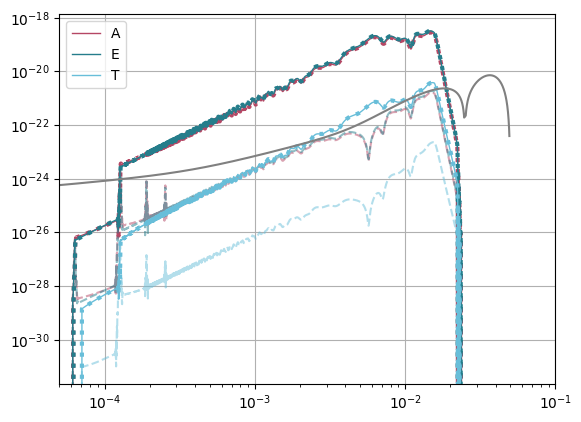

In [154]:
ch_names = ["A", "E", "T"]
ch_colors = [RED, GREEN1, BLUE]
psdfunc = TDIPSDs()
for i in range(3):
    plt.loglog(data_frequencies, np.abs(wf_channels1[i]) * 2. * data_frequencies, color=ch_colors[i], label=ch_names[i], linestyle="-", linewidth=1)
    plt.loglog(data_frequencies, np.abs(wf_channels2[i]) * 2. * data_frequencies, color=ch_colors[i], linestyle=":", linewidth=3)
    plt.loglog(data_frequencies, np.abs(wf_channels1[i] - wf_channels2[i]) * 2. * data_frequencies, color=ch_colors[i], linestyle="--", alpha=0.5)
plt.loglog(data_frequencies, np.sqrt(psdfunc.PSD_X2(data_frequencies) * data_frequencies), color="grey")
plt.legend()
plt.grid()
# plt.ylim(1e-25,)
plt.xlim(5e-5, 0.1)

In [155]:
f1, amp1, pha1, tf1 = WFG1(
    parameters=mbhb_parameters, 
    Nfreqs=1024, 
    fmin=1e-5, 
    fmax=0.1, 
)

f2, amp2, pha2, tf2 = WFG2(
    parameters=mbhb_parameters, 
    Nfreqs=1024, 
    fmin=1e-5, 
    fmax=0.1, 
    f_ref=WFG1.f_ref[0]
)

np.max(f1-f2)

0.0

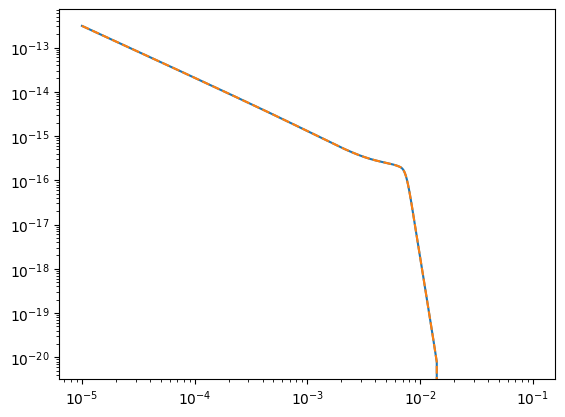

In [156]:
plt.loglog(f1[0], amp1[(2,2)][0])
plt.loglog(f2[0], amp2[(2,2)][0], linestyle="--")

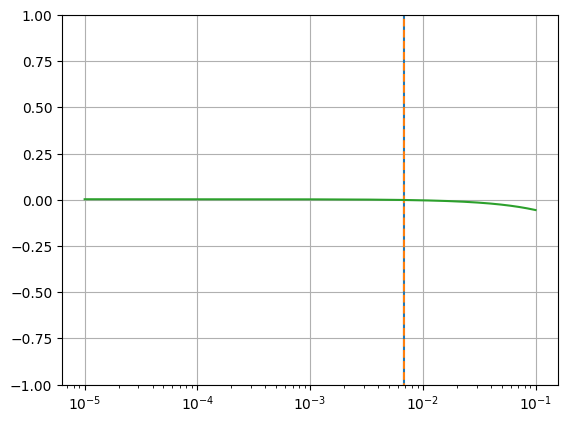

In [157]:
plt.semilogx(f1[0], pha1[(2,2)][0])
plt.semilogx(f2[0], pha2[(2,2)][0], linestyle="--")
plt.semilogx(f1[0], pha1[(2,2)][0]-pha2[(2,2)][0])
plt.ylim(-1, 1)
plt.grid()

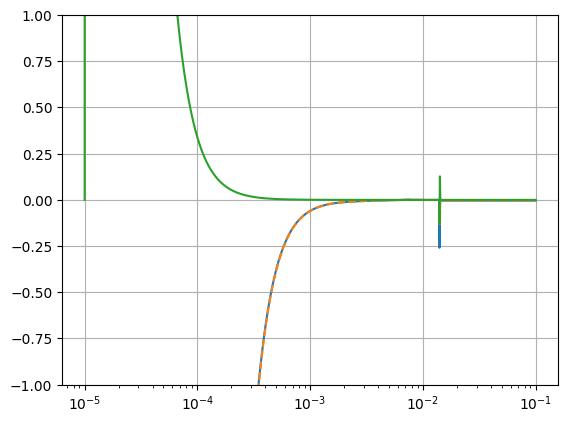

In [158]:
plt.semilogx(f1[0], tf1[(2,2)][0] / DAY - mbhb_parameters["coalescence_time"])
plt.semilogx(f2[0], tf2[(2,2)][0] / DAY - mbhb_parameters["coalescence_time"], linestyle="--")
plt.semilogx(f1[0], tf1[(2,2)][0] / DAY - tf2[(2,2)][0] / DAY)
plt.ylim(-1, 1)
plt.grid()